# Network Intrusion Detection System
#### Artificial Intelligence Semester Project
***Instructor: Sir Saad Ahmed***

Group Members : Muhammad Muddasir (24P-0524) & Fida Hussain (24P-0676)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

import random
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


# Task 1  Data Exploration

In [27]:
df = pd.read_csv('network_traffic.csv')

print('Shape:', df.shape)
print('First 5 rows:')
df.head()

Shape: (6000, 16)
First 5 rows:


,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
0,0,244,3252,0,0,1,0,16,16,0.0,1.00,0.00,34,255,1.00,0
1,0,8,0,0,0,0,0,1,21,0.0,1.00,0.00,1,41,1.00,1
2,0,242,5278,0,0,1,0,6,11,0.0,1.00,0.00,255,255,1.00,0
3,0,45,76,0,0,0,0,161,161,0.0,1.00,0.00,255,203,0.80,0
4,0,1,0,0,0,0,0,13,2,0.0,0.15,0.15,255,29,0.11,1


In [8]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
count,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,413.933000,1.603307e+04,2.951740e+03,0.028333,0.206167,0.385000,0.179667,80.434500,27.572333,0.293578,0.658218,0.060692,180.643333,112.433000,0.519193,0.500000
std,3237.030266,3.049754e+05,7.057366e+04,0.283803,2.120632,0.486636,8.981360,108.869318,70.945265,0.451700,0.438878,0.170613,99.879900,108.894863,0.445222,0.500042
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.100000,0.000000,79.000000,11.000000,0.050000,0.000000
50%,0.000000,4.300000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,1.000000,0.000000,255.000000,60.000000,0.490000,0.500000
75%,0.000000,2.730000e+02,4.550000e+02,0.000000,0.000000,1.000000,0.000000,135.250000,18.000000,1.000000,1.000000,0.060000,255.000000,255.000000,1.000000,1.000000
max,42569.000000,1.698050e+07,5.149533e+06,3.000000,30.000000,1.000000,520.000000,511.000000,511.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000


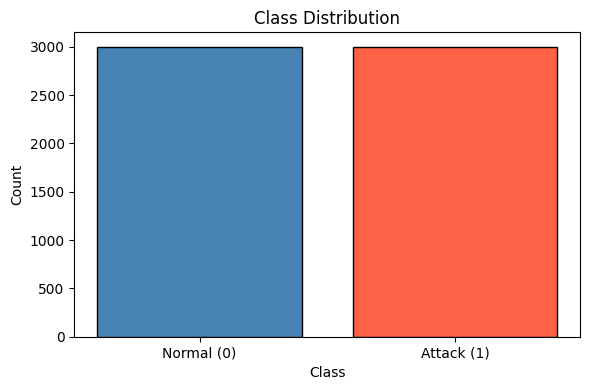

Normal: 3000  |  Attack: 3000


In [28]:
class_counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Normal (0)', 'Attack (1)'], class_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Normal: {class_counts[0]}  |  Attack: {class_counts[1]}')

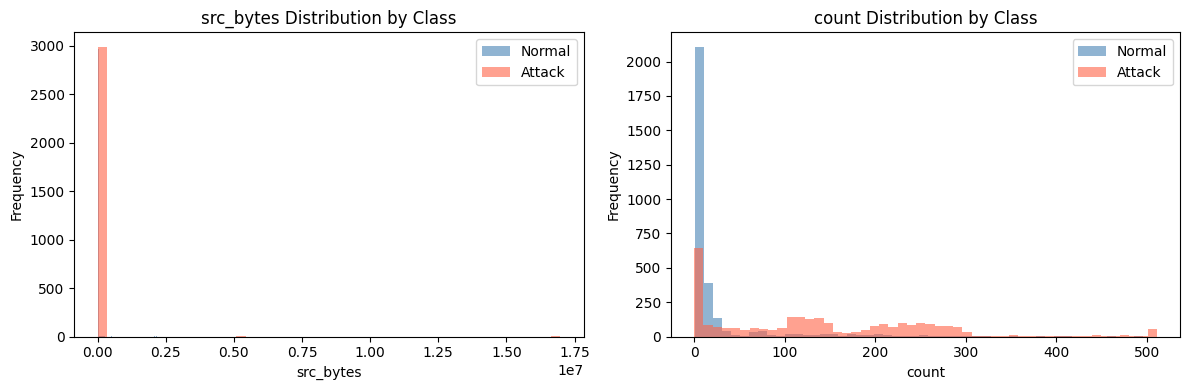

In [29]:
normal = df[df['label'] == 0]
attack = df[df['label'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(normal['src_bytes'], bins=50, alpha=0.6, color='steelblue', label='Normal')
axes[0].hist(attack['src_bytes'], bins=50, alpha=0.6, color='tomato', label='Attack')
axes[0].set_title('src_bytes Distribution by Class')
axes[0].set_xlabel('src_bytes')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(normal['count'], bins=50, alpha=0.6, color='steelblue', label='Normal')
axes[1].hist(attack['count'], bins=50, alpha=0.6, color='tomato', label='Attack')
axes[1].set_title('count Distribution by Class')
axes[1].set_xlabel('count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Task 2 Simple Reflex Agent (Rule-Based Baseline)

In [31]:
def reflex_agent(row):
    
    if row['serror_rate'] > 0.5:
        return 1
    if row['same_srv_rate'] < 0.4 and row['diff_srv_rate'] > 0.5:
        return 1
    if row['count'] > 200 and row['serror_rate'] > 0.1:
        return 1
    return 0

df['agent_pred'] = df.apply(reflex_agent, axis=1)

agent_acc = accuracy_score(df['label'], df['agent_pred'])
print(f'Reflex Agent Accuracy: {agent_acc:.4f} ({agent_acc*100:.2f}%)')

Reflex Agent Accuracy: 0.8052 (80.52%)


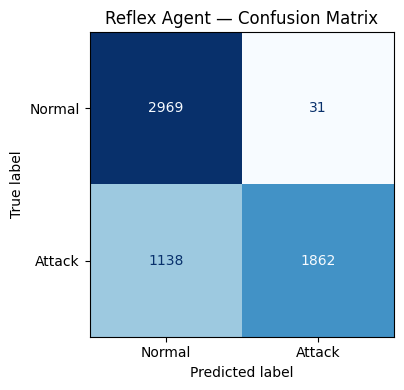

In [32]:
cm_agent = confusion_matrix(df['label'], df['agent_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_agent, display_labels=['Normal', 'Attack'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Reflex Agent — Confusion Matrix')
plt.tight_layout()
plt.show()

# Why is this a Simple Reflex Agent?

It agent acts solely on the current percept it maps each input directly to an action using a fixed set of if else rules, with no memory of past inputs and no internal state. Here, reflex_agent(row) receives a single connection record (the percept), checks a small number of feature thresholds (the rules), and immediately returns a classification (the action). There is no learning, no history, and no reasoning about future consequences it is a pure percept → rule → action pipeline, which is the defining characteristic of a simple reflex agent.

# Task 3  Supervised Learning

In [33]:
FEATURE_COLS = [c for c in df.columns if c != 'label']
X = df[FEATURE_COLS]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')


Train size: 4800  |  Test size: 1200


In [34]:
k_values = [1, 3, 5, 7, 9, 11]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    knn_accuracies.append(acc)
    print(f'  k={k:2d}  accuracy={acc:.4f}')

best_k = k_values[np.argmax(knn_accuracies)]
print(f'\nBest k = {best_k}  (accuracy = {max(knn_accuracies):.4f})')

  k= 1  accuracy=0.9542
  k= 3  accuracy=0.9542
  k= 5  accuracy=0.9542
  k= 7  accuracy=0.9517
  k= 9  accuracy=0.9508
  k=11  accuracy=0.9433

Best k = 1  (accuracy = 0.9542)


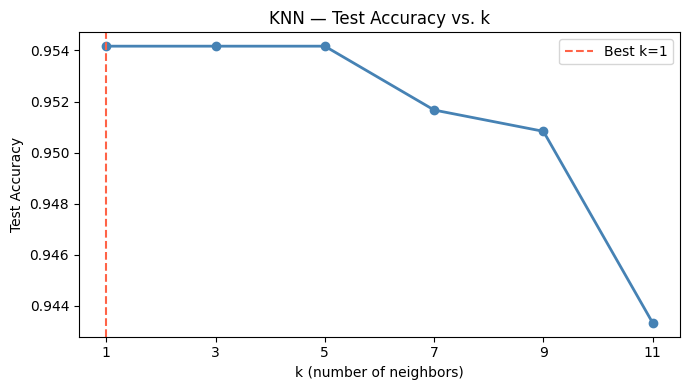

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_accuracies, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
plt.title('KNN — Test Accuracy vs. k')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Train final KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

# Naïve Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('All classifiers trained.')

All classifiers trained.


In [41]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1-Score':  round(f1_score(y_true, y_pred),        4),
    }

results = [
    get_metrics(y_test, y_pred_knn, f'KNN (k={best_k})'),
    get_metrics(y_test, y_pred_nb,  'Naïve Bayes'),
    get_metrics(y_test, y_pred_lr,  'Logistic Regression'),
]

results_df = pd.DataFrame(results).set_index('Model')
print('\n\t\t\tComparison Table\n')
print(results_df.to_string())


			Comparison Table

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
KNN (k=1)              0.9542     0.9431  0.9667    0.9547
Naïve Bayes            0.7875     0.9367  0.6167    0.7437
Logistic Regression    0.9142     0.9233  0.9033    0.9132


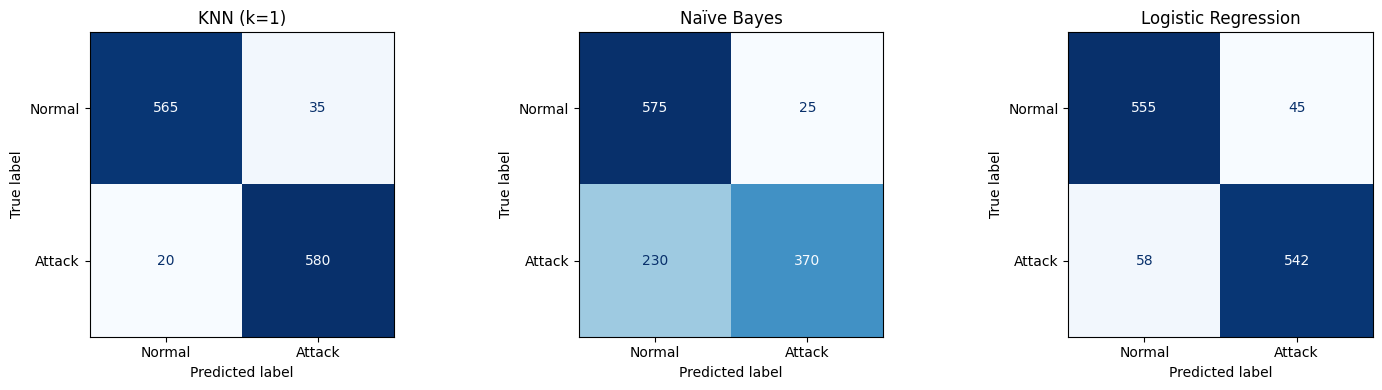

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
classifiers = [
    (y_pred_knn, f'KNN (k={best_k})'),
    (y_pred_nb,  'Naïve Bayes'),
    (y_pred_lr,  'Logistic Regression'),
]

for ax, (y_pred, name) in zip(axes, classifiers):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}')

plt.tight_layout()
plt.show()

# Task 4 Clustering with K-Means

In [43]:
X_unlabeled = df[FEATURE_COLS]
scaler_km = StandardScaler()
X_scaled_km = scaler_km.fit_transform(X_unlabeled)

# Fit K-Means
km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled_km)

# Confusion matrix — cluster IDs vs true labels
cm_km = confusion_matrix(df['label'], cluster_labels)
print('Confusion matrix (rows=true label, cols=cluster id):')
print(cm_km)
print()

acc_direct = accuracy_score(df['label'], cluster_labels)
acc_flipped = accuracy_score(df['label'], 1 - cluster_labels)
km_accuracy = max(acc_direct, acc_flipped)
print(f'K-Means clustering accuracy (best orientation): {km_accuracy:.4f}')


Confusion matrix (rows=true label, cols=cluster id):
[[2937   63]
 [ 777 2223]]

K-Means clustering accuracy (best orientation): 0.8600


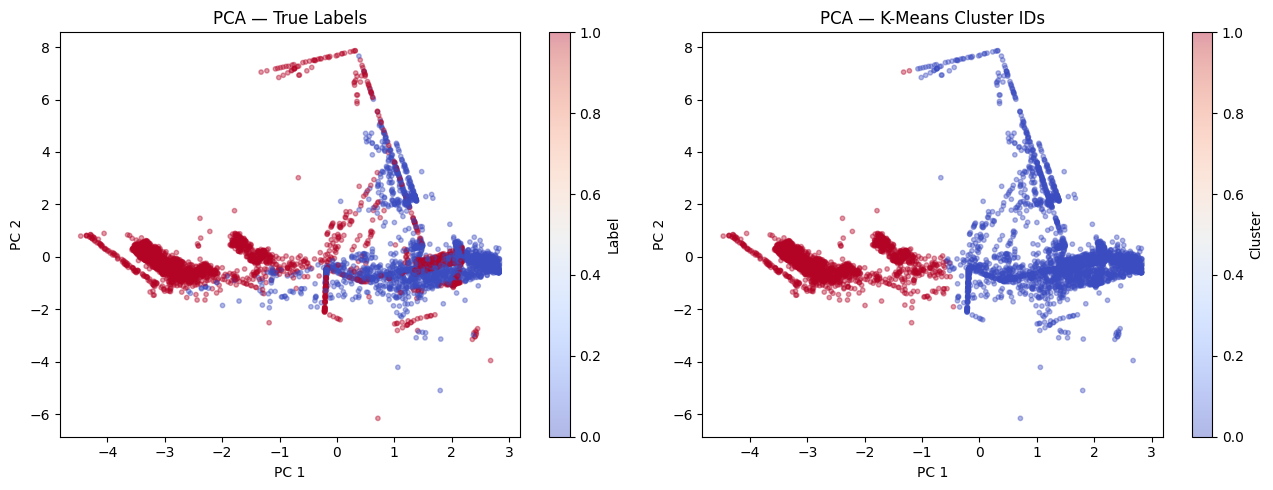

In [44]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_km)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter0 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['label'], cmap='coolwarm', alpha=0.4, s=10
)

axes[0].set_title('PCA — True Labels')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
plt.colorbar(scatter0, ax=axes[0], label='Label')

scatter1 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap='coolwarm', alpha=0.4, s=10
)

axes[1].set_title('PCA — K-Means Cluster IDs')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
plt.colorbar(scatter1, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Task 5 Genetic Algorithm for Feature Selection

In [45]:
# GA setup
FEATURES = list(X.columns)
N_FEATURES = len(FEATURES)
POP_SIZE = 10
N_GENERATIONS = 10
MUTATION_RATE = 0.1
random.seed(42)
np.random.seed(42)

def fitness(chromosome):
    """Test accuracy of Logistic Regression trained on the selected features."""
    selected = [FEATURES[i] for i, bit in enumerate(chromosome) if bit == 1]
    if not selected:          # at least one feature must be selected
        return 0.0
    X_tr = X_train_scaled[:, [FEATURES.index(f) for f in selected]]
    X_te = X_test_scaled[:,  [FEATURES.index(f) for f in selected]]
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_train)
    return accuracy_score(y_test, model.predict(X_te))

def init_population(pop_size, n_features):
    return [[random.randint(0, 1) for _ in range(n_features)] for _ in range(pop_size)]

def selection(population, fitnesses):
    """Tournament selection — pick the better of two random individuals."""
    selected = []
    for _ in range(len(population)):
        a, b = random.sample(range(len(population)), 2)
        selected.append(population[a] if fitnesses[a] >= fitnesses[b] else population[b])
    return selected

def crossover(parent1, parent2):
    """One-point crossover."""
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def mutate(chromosome, rate=MUTATION_RATE):
    """Bit-flip mutation."""
    return [1 - bit if random.random() < rate else bit for bit in chromosome]

print('GA functions defined.')

GA functions defined.


In [46]:
population = init_population(POP_SIZE, N_FEATURES)
best_chromosome = None
best_fitness = 0.0
history = []

for gen in range(N_GENERATIONS):
    fitnesses = [fitness(chrom) for chrom in population]

    gen_best_idx = np.argmax(fitnesses)
    gen_best_fit = fitnesses[gen_best_idx]
    history.append(gen_best_fit)

    if gen_best_fit > best_fitness:
        best_fitness = gen_best_fit
        best_chromosome = population[gen_best_idx][:]

    print(f'Generation {gen+1:2d}  best_accuracy={gen_best_fit:.4f}')

    selected = selection(population, fitnesses)
    next_gen = []
    for i in range(0, POP_SIZE, 2):
        p1, p2 = selected[i], selected[(i + 1) % POP_SIZE]
        c1, c2 = crossover(p1, p2)
        next_gen.extend([mutate(c1), mutate(c2)])
    population = next_gen[:POP_SIZE]

# Best result
best_features = [FEATURES[i] for i, bit in enumerate(best_chromosome) if bit == 1]
print(f'\nBest subset ({len(best_features)} features): {best_features}')
print(f'GA best accuracy:  {best_fitness:.4f}')
print(f'All-features LR:   {results_df.loc["Logistic Regression", "Accuracy"]:.4f}')

Generation  1  best_accuracy=0.8833
Generation  2  best_accuracy=0.8992
Generation  3  best_accuracy=0.9092
Generation  4  best_accuracy=0.9067
Generation  5  best_accuracy=0.9067
Generation  6  best_accuracy=0.9158
Generation  7  best_accuracy=0.9142
Generation  8  best_accuracy=0.9142
Generation  9  best_accuracy=0.9050
Generation 10  best_accuracy=0.9150

Best subset (10 features): ['duration', 'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised', 'count', 'same_srv_rate', 'dst_host_count', 'agent_pred']
GA best accuracy:  0.9158
All-features LR:   0.9142


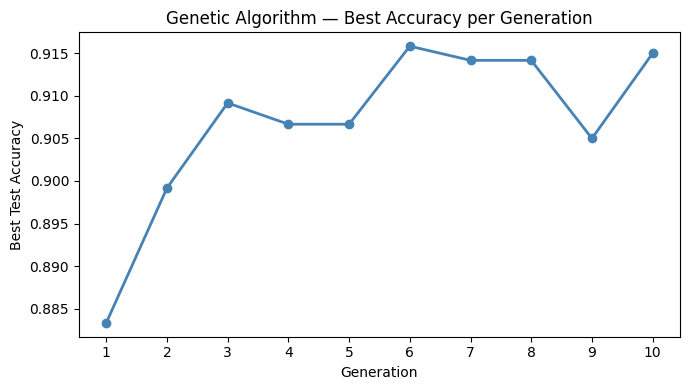


Features used by GA subset : 10 / 16
The reduced model is simpler (fewer features) and may train/infer faster,
while achieving comparable accuracy to the full-feature model.


In [47]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, N_GENERATIONS + 1), history, marker='o', color='steelblue', linewidth=2)
plt.title('Genetic Algorithm — Best Accuracy per Generation')
plt.xlabel('Generation')
plt.ylabel('Best Test Accuracy')
plt.xticks(range(1, N_GENERATIONS + 1))
plt.tight_layout()
plt.show()

print(f'\nFeatures used by GA subset : {len(best_features)} / {N_FEATURES}')
print('The reduced model is simpler (fewer features) and may train/infer faster,')
print('while achieving comparable accuracy to the full-feature model.')